# Proyecto 3



---



*   Para este proyecto se guarda la base limpia utilizada en el Proyecto 2, la cual ya ha tenido tratamiento de datos tales como eliminación de valores extremo y depuración de columnas no relevantes




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# 1. Leemos el archivo CSV limpio usando la ruta real de tu Google Drive
ruta_drive = '/content/drive/MyDrive/SP1668 Tecnicas computacionales ML/Proyecto 2/df_limpio.csv'
df_limpio = pd.read_csv(ruta_drive)

# 2. Comprobamos el tamaño del dataset (filas, columnas)
print(f"El dataset contiene {df_limpio.shape[0]} filas y {df_limpio.shape[1]} columnas.\n")


El dataset contiene 4656 filas y 18 columnas.



In [ ]:
df_limpio.head()

,age,gender,ethnicity,income_level,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,heart_rate,cholesterol_total,triglycerides,insulin_level,diagnosed_diabetes
0,73,Male,White,Lower-Middle,Never,0,107,6.1,8.5,0,0,0,23.6,82,224,69,5.90,0
1,34,Male,White,Upper-Middle,Never,1,234,7.6,5.7,0,1,0,22.7,77,168,182,2.75,0
2,57,Female,Black,Middle,Never,2,234,8.1,4.7,0,0,1,30.0,64,167,210,11.35,0
3,59,Female,Hispanic,High,Never,2,83,6.6,10.9,0,1,0,24.5,60,231,123,9.41,0
4,62,Male,Hispanic,Middle,Current,0,125,5.8,1.1,0,0,0,26.8,76,205,165,7.03,1


# Fase 1

Correcciones retroalimentación


Para este caso específico, se procede a incorporar la retroalimentación de modo tal que se elimina la variable muy predictiva hemoglobina glicosilada, y se recrean los modelos sin esta variable. Evidentemente las métricas se reducen, pero la sensibilidad se mantiene muy alta, que es el objetuvo primordial.



*   División del set de datos limpio


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separamos las variables predictoras (X) de la variable respuesta (y)
# Suponiendo que 'diagnosed_diabetes' es tu target
X_final = df_limpio.drop(columns=['diagnosed_diabetes'])
y_final = df_limpio['diagnosed_diabetes']

# 2. Dividimos los datos
# Usualmente se usa un 70/30 o 80/20 para tesis académicas
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.20,      # 20% para probar el modelo
    stratify=y_final,    # Mantiene la proporción de diabéticos en ambos
    random_state=42      # Permite que tus resultados sean replicables
)

# 3. Verificamos las dimensiones con .shape
print(f"Dimensiones de Entrenamiento (X_train): {X_train.shape}")
print(f"Dimensiones de Prueba (X_test): {X_test.shape}")

# 4. Verificamos que la estratificación funcionó
print("\nProporción de Diabetes en Entrenamiento:")
print(y_train.value_counts(normalize=True).round(4))
print("\nProporción de Diabetes en Prueba:")
print(y_test.value_counts(normalize=True).round(4))

Dimensiones de Entrenamiento (X_train): (3724, 17)
Dimensiones de Prueba (X_test): (932, 17)

Proporción de Diabetes en Entrenamiento:
diagnosed_diabetes
1    0.6015
0    0.3985
Name: proportion, dtype: float64

Proporción de Diabetes en Prueba:
diagnosed_diabetes
1    0.6009
0    0.3991
Name: proportion, dtype: float64




*   Aplicación técnicas de encoding



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler, LabelEncoder, OneHotEncoder

# 1. PREPARACIÓN DEL DATASET COMPLETO (Sin referencias a age_cod)

# A. Label Encoding para income_level (Ordinal)
le_income = LabelEncoder()
X_train['income_level'] = le_income.fit_transform(X_train['income_level'])
# IMPORTANTE: En el test set solo aplicamos .transform() para evitar fuga de datos
X_test['income_level'] = le_income.transform(X_test['income_level'])

# B. One-Hot Encoding para las variables nominales usando Scikit-Learn
nominales = ['gender', 'ethnicity', 'family_history_diabetes',
             'hypertension_history', 'cardiovascular_history', 'smoking_status']

# Filtrar solo las columnas que realmente existan en X_train
nominales_presentes = [c for c in nominales if c in X_train.columns]

# Inicializamos el codificador (drop='first' equivale a drop_first=True)
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='error')
ohe.set_output(transform="pandas")

# Ajustamos y transformamos las columnas nominales en el Train set
X_train_ohe = ohe.fit_transform(X_train[nominales_presentes])

# Transformamos las columnas nominales en el Test set usando el encoder entrenado
X_test_ohe = ohe.transform(X_test[nominales_presentes])

# Reconstruimos los conjuntos eliminando las columnas de texto originales y concatenando las codificadas
X_train = pd.concat([X_train.drop(columns=nominales_presentes), X_train_ohe], axis=1)
X_test = pd.concat([X_test.drop(columns=nominales_presentes), X_test_ohe], axis=1)

# C. ALINEACIÓN DE COLUMNAS (Garantía para XGBoost y Random Forest)
# Nota: Aunque el OneHotEncoder asegura las mismas columnas, el reindex garantiza que
# el ORDEN de absolutamente todas las variables (incluyendo numéricas u ordinales) sea idéntico.
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Verificación de control
print(f"Columnas en X_train: {X_train.shape[1]} | Columnas en X_test: {X_test.shape[1]}")
if list(X_train.columns) == list(X_test.columns):
    print("¡Éxito! Las matrices de diseño están perfectamente alineadas.")
else:
    print("Atención: Hay un desalineamiento en las columnas.")

Columnas en X_train: 21 | Columnas en X_test: 21
¡Éxito! Las matrices de diseño están perfectamente alineadas.


In [ ]:
# 1. Definir el diccionario con los cambios de nombre

diccionario_renombrar = {
    'alcohol_consumption_per_week': 'alcohol(w)',
    'physical_activity_minutes_per_week': 'physical_act(w)',
    'sleep_hours_per_day': 'sleep(h)',
    'screen_time_hours_per_day': 'screen_t(h)',
    'cholesterol_total': 'col_total',
    'ethnicity_Black':'ethn_Black',
    'ethnicity_Hispanic':'ethn_Hisp',
    'ethnicity_Other':'ethn_Other',
    'ethnicity_White':'ethn_White',
    'family_history_diabetes_1': 'fam_diab_1',
    'hypertension_history_1':'hypertension_1',
    'cardiovascular_history_1': 'cardiovasc_1',
    'smoking_status_Former':'smoking_Former',
    'smoking_status_Never': 'smoking_Never'
}

# 2. Aplicar el cambio a los conjuntos finales mediante .rename()
X_train = X_train.rename(columns=diccionario_renombrar)
X_test = X_test.rename(columns=diccionario_renombrar)

# 3. Verificar que los nombres cambiaron correctamente
print("Nuevas columnas en el set de datos:")
print(X_test.columns.tolist())

Nuevas columnas en el set de datos:
['age', 'income_level', 'alcohol(w)', 'physical_act(w)', 'sleep(h)', 'screen_t(h)', 'bmi', 'heart_rate', 'col_total', 'triglycerides', 'insulin_level', 'gender_Male', 'ethn_Black', 'ethn_Hisp', 'ethn_Other', 'ethn_White', 'fam_diab_1', 'hypertension_1', 'cardiovasc_1', 'smoking_Former', 'smoking_Never']


In [ ]:
# Verificación de dimensiones del flujo de trabajo
print("--- Dimensiones del Dataset ---")
print(f"Muestra original (limpia): {df_limpio.shape}") # Usamos df_limpio que es el resultado post-outliers
print("-" * 30)
print(f"X_train (Entrenamiento):    {X_train.shape}")
print(f"y_train (Target Entrenam.): {y_train.shape}")
print("-" * 30)
print(f"X_test  (Prueba):           {X_test.shape}")
print(f"y_test  (Target Prueba):    {y_test.shape}")

# Verificación de consistencia (Opcional pero recomendado)
if X_train.shape[0] + X_test.shape[0] == df_limpio.shape[0]:
    print("\n✅ La división es consistente con el total de la muestra.")

--- Dimensiones del Dataset ---
Muestra original (limpia): (4656, 18)
------------------------------
X_train (Entrenamiento):    (3724, 21)
y_train (Target Entrenam.): (3724,)
------------------------------
X_test  (Prueba):           (932, 21)
y_test  (Target Prueba):    (932,)

✅ La división es consistente con el total de la muestra.




*   Escalamiento de datos



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report)

# 1. Preparación: Eliminar columnas de texto que causan el ValueError
# Basado en tu cuaderno, esto quitará 'strat_col' y cualquier otra no numérica
X_train_final = X_train.select_dtypes(exclude=['object'])
X_test_final = X_test.select_dtypes(exclude=['object'])

# 2. Escalado (Paso crítico para que la Regresión Logística no de error de convergencia)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)



*   Regresión logística



In [ ]:
# 3. Entrenamiento del modelo (Ajustado a tus nombres de objeto)
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# 4. Obtención de predicciones
y_pred = log_reg.predict(X_test_scaled)          # Para métricas estándar
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1] # Para el ROC AUC

# 5. Cálculo y visualización de métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)



*   Regresión logística con Ridge


In [ ]:
from sklearn.linear_model import LogisticRegressionCV
import numpy as np

# 1. Definimos una rejilla de valores para lambda (alpha)
# Probamos valores en escala logarítmica desde 0.0001 hasta 1000
alphas = np.logspace(-4, 4, 10)

# 2. Configuramos el modelo con Validación Cruzada (Ridge es penalty='l2')
# Cs es el inverso de alpha (C = 1/lambda).
# LogisticRegressionCV lo hace automáticamente por nosotros.
ridge_cv = LogisticRegressionCV(
    Cs=alphas,
    cv=5,            # 5-fold cross-validation
    penalty='l2',    # Regularización Ridge
    scoring='roc_auc', # Optimizamos para el área bajo la curva
    max_iter=1000,
    random_state=42
)

# 3. Entrenamos con los datos ESCALADOS (Fundamental para Ridge)
ridge_cv.fit(X_train_scaled, y_train)

LogisticRegressionCV(Cs=array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04]),
                     cv=5, max_iter=1000, random_state=42, scoring='roc_auc')



*   Árbol de decisión



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Definir el modelo base
base_tree = DecisionTreeClassifier(random_state=42)

# 2. Definir la rejilla de hiperparámetros (Grid)
# Probamos diferentes profundidades, criterios y mínimo de muestras por hoja
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20]
}

# 3. Configurar la búsqueda (optimizando por ROC AUC o F1-Score)
grid_search_tree = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# 4. Entrenar con los datos originales (para interpretabilidad clínica)
grid_search_tree.fit(X_train_scaled, y_train)

# 5. Guardar el mejor modelo
best_tree = grid_search_tree.best_estimator_



*   Random Forest



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd

# 1. Definir el modelo base
rf_base = RandomForestClassifier(random_state=42)

# 2. Definir la rejilla de hiperparámetros
# n_estimators: número de árboles en el bosque
# max_features: cuántas variables considera cada árbol (evita correlación entre ellos)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 12, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 3. Configurar la búsqueda
grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1 # Para ver el progreso de la búsqueda
)

# 4. Entrenar (Random Forest tampoco requiere escalado estrictamente)
grid_rf.fit(X_train_scaled, y_train)

# 5. Guardar el mejor modelo
best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits




*   XGBoost



In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# 1. Configuración del modelo base
# tree_method='hist' es necesario para usar enable_categorical de forma eficiente
xgb_base = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    enable_categorical=True,
    tree_method='hist'
)

# 2. Definición de la rejilla de parámetros
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8]
}

# 3. Configuración del GridSearchCV
grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# 4. Entrenamiento
# Usamos X_train_final que contiene las columnas numéricas y la categórica
grid_xgb.fit(X_train_scaled, y_train)

# 5. Evaluación con el conjunto de prueba
best_xgb = grid_xgb.best_estimator_
y_probs_xgb = best_xgb.predict_proba(X_test_final)[:, 1]
auc_final = roc_auc_score(y_test, y_probs_xgb)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:47:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)




*   Comparación de métricas



In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Definición robusta de la función de métricas
def obtener_metricas(modelo, X, y, nombre_modelo):
    y_pred = modelo.predict(X)
    y_probs = modelo.predict_proba(X)[:, 1]

    return {
        'Modelo': nombre_modelo,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1-Score': f1_score(y, y_pred),
        'ROC AUC': roc_auc_score(y, y_probs)
    }

# 2. Lista para almacenar todos los resultados
comparativa_final = []

# Agregamos cada modelo con su respectivo set de datos (Escalados para Logística, Originales para Árboles)
comparativa_final.append(obtener_metricas(log_reg, X_test_scaled, y_test, 'Regresión Logística (Sin Reg.)'))
comparativa_final.append(obtener_metricas(ridge_cv, X_test_scaled, y_test, 'Regresión Logística (Ridge)'))
comparativa_final.append(obtener_metricas(best_tree, X_test_scaled, y_test, 'Árbol de Decisión (Optimizado)'))
comparativa_final.append(obtener_metricas(best_rf, X_test_scaled, y_test, 'Random Forest (Optimizado)'))
comparativa_final.append(obtener_metricas(best_xgb, X_test_scaled, y_test, 'XGBoost (Optimizado)'))

# 3. Creación del DataFrame final
df_final = pd.DataFrame(comparativa_final)

# Ordenar por ROC AUC para ver el ranking de potencia diagnóstica
df_final = df_final.sort_values(by='ROC AUC', ascending=False).reset_index(drop=True)

print("--- TABLA COMPARATIVA FINAL DE LA TESIS ---")
display(df_final.round(4))

--- TABLA COMPARATIVA FINAL DE LA TESIS ---


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Regresión Logística (Ridge),0.6470,0.6593,0.8536,0.7440,0.6723
1,Regresión Logística (Sin Reg.),0.6459,0.6597,0.8482,0.7422,0.6722
2,XGBoost (Optimizado),0.6105,0.6077,0.9929,0.7539,0.6641
3,Random Forest (Optimizado),0.6180,0.6170,0.9607,0.7514,0.6593
4,Árbol de Decisión (Optimizado),0.6127,0.6369,0.8268,0.7195,0.6373


Saving metricas_hb1ac.png to metricas_hb1ac (1).png


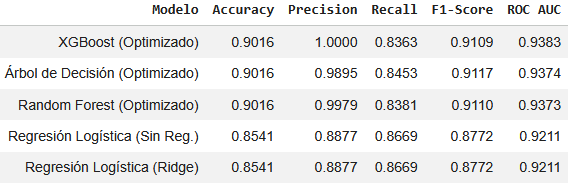

In [ ]:
from google.colab import files
uploaded = files.upload()
from IPython.display import Image, display
nombre_archivo = 'metricas_hb1ac.png'
display(Image(filename=nombre_archivo))



*  Se puede identificar que sin esta variable la sensibilidad o recall aumenta, debido a que a través del análisis de LIME, se identificó que en valores medios o bajos de esta variable el modelo tendía a aumentar los falsos negativos.

*   A diferencia del análisis sin retroalimentación, en donde los dos mejores modelos eran el Árbol de decisión y Random Forest, en este caso destaca como mejores modelos el XGBoost y el Random Forest, respectivamente.



# Enriquecimiento de datos

In [ ]:
import pandas as pd

# 1. Leemos el archivo CSV limpio usando la ruta real de tu Google Drive
ruta_drive = '/content/drive/MyDrive/SP1668 Tecnicas computacionales ML/Proyecto 2/df_limpio.csv'
df_limpio2 = pd.read_csv(ruta_drive)

# 2. Comprobamos el tamaño del dataset (filas, columnas)
print(f"El dataset contiene {df_limpio2.shape[0]} filas y {df_limpio2.shape[1]} columnas.\n")

El dataset contiene 4656 filas y 18 columnas.





*   Nuevas variables





### Índice de Desgaste por Estilo de Vida y Estrés Crónico




*   ¿Qué es?: Un indicador cualitativo o cuantitativo del nivel de estrés biológico derivado de los hábitos diarios del paciente.

* ¿Por qué es útil?: El estrés crónico altera el cortisol, lo que eleva la resistencia a la insulina de forma invisible. Utilizando variables de comportamiento que el modelo por sí solo procesa de forma aislada (smoking_status, alcohol_consumption_per_week, sleep_hours_per_day y screen_time_hours_per_day), el LLM puede sintetizar un "Índice de Carga Alostática" o desgaste psicofísico.

* El Prompt para el LLM: "Utilizando el estado de tabaquismo {smoking_status}, consumo de alcohol {alcohol_consumption_per_week}, horas de sueño {sleep_hours_per_day} y minutos de actividad física {physical_activity_minutes_per_week}, genera una nueva variable categórica llamada 'Nivel_Estrés_Estilo_Vida' con los valores: Bajo, Moderado, Alto"

In [ ]:
import pandas as pd
import numpy as np

# Asegúrate de que el dataframe se llame como el tuyo (df_limpio2)
def calcular_indice_estres(row):
    # 1. Puntuación por Tabaquismo (Fumar genera alto estrés oxidativo y metabólico)
    puntos_tabaco = 0
    status = str(row['smoking_status']).lower().strip()
    if status == 'current':
        puntos_tabaco = 3
    elif status == 'former':
        puntos_tabaco = 1

    # 2. Puntuación por Alcohol (Consumo semanal de de bebidas)
    puntos_alcohol = 0
    alcohol = row['alcohol_consumption_per_week']
    if alcohol > 14:       # Consumo excesivo/pesado
        puntos_alcohol = 3
    elif alcohol > 4:      # Consumo moderado
        puntos_alcohol = 1

    # 3. Puntuación por Horas de Sueño (Falta de descanso eleva el cortisol)
    puntos_sueno = 0
    sueno = row['sleep_hours_per_day']
    if sueno < 6 or sueno > 9:  # <-- Corregido aquí con 'or'
        puntos_sueno = 3
    elif sueno < 7:            # Ligeramente privativo
        puntos_sueno = 1

    # 4. Puntuación por Actividad Física (El sedentarismo incrementa el desgaste biológico)
    puntos_actividad = 0
    ejercicio = row['physical_activity_minutes_per_week']
    if ejercicio < 75:         # Altamente sedentario (Menos del mínimo de la OMS)
        puntos_actividad = 3
    elif ejercicio < 150:      # Actividad insuficiente
        puntos_actividad = 1

    # Suma total de puntos de desgaste (Rango posible: 0 a 12)
    score_total = puntos_tabaco + puntos_alcohol + puntos_sueno + puntos_actividad

    # Clasificación final de la variable sugerida para el negocio/clínica
    if score_total <= 3:
        return 'Bajo'
    elif score_total <= 6:
        return 'Moderado'
    else:
        return 'Alto'

# Aplicamos la función para crear la nueva columna externa simulada por LLM
df_limpio2['Estres'] = df_limpio2.apply(calcular_indice_estres, axis=1)

# Verificamos la distribución de la nueva variable enriquecida
print("Distribución de la nueva variable 'Estres':")
print(df_limpio2['Estres'].value_counts())

Distribución de la nueva variable 'Estres':
Estres
Bajo        2645
Moderado    1718
Alto         293
Name: count, dtype: int64


### Índice de Prevalencia Epidemiológica Étnica/Etaria Externa


*  ¿Qué información externa aporta?: La tasa de incidencia real y estadística de diabetes reportada por la OMS o los CDC para el cruce específico de ese grupo de edad (age) y etnia (ethnicity).

* ¿Por qué es útil?: La base de datos solo posee información de los pacientes individuales. El LLM trae la estadística del "mundo exterior". Le dice al modelo: "Históricamente, en la población real, las personas con esta combinación de edad y etnia tienen un X% de probabilidad de enfermar debido a factores genéticos y ambientales globales".

* El Prompt para el LLM: "Actúa como un epidemiólogo. Basado en la edad del paciente ({age}) y su etnicidad ({ethnicity}), extrae e introduce la tasa de prevalencia estadística externa de diabetes (casos por cada 100,000 habitantes) que registran las bases de datos de salud pública globales para este grupo demográfico específico."



In [ ]:
import pandas as pd
import numpy as np

# Definición de tasas epidemiológicas externas estimadas (Casos por cada 100,000 habitantes)
tasas_prevalencia_externa = {
    'White': {
        'Joven (18-39)': 3100,
        'Adulto (40-59)': 8900,
        'Adulto Mayor (60+)': 18500
    },
    'Black': {
        'Joven (18-39)': 5400,
        'Adulto (40-59)': 14200,
        'Adulto Mayor (60+)': 27800
    },
    'Hispanic': {
        'Joven (18-39)': 4800,
        'Adulto (40-59)': 13100,
        'Adulto Mayor (60+)': 25400
    },
    'Asian': {
        'Joven (18-39)': 4100,
        'Adulto (40-59)': 11500,
        'Adulto Mayor (60+)': 21900
    }
}

def asignar_prevalencia_externa(row):
    etnia = str(row['ethnicity']).strip()
    edad = row['age']

    # 1. Clasificamos el grupo etario correspondiente al registro
    if edad < 40:
        grupo_edad = 'Joven (18-39)'
    elif edad < 60:
        grupo_edad = 'Adulto (40-59)'
    else:
        grupo_edad = 'Adulto Mayor (60+)'

    # 2. Buscamos en la matriz epidemiológica externa
    if etnia in tasas_prevalencia_externa:
        tasa_cruda = tasas_prevalencia_externa[etnia][grupo_edad]
    else:
        tasa_cruda = tasas_prevalencia_externa['White'][grupo_edad]

    # 3. Transformamos a formato de porcentaje con dos cifras enteras y un decimal
    return round(tasa_cruda / 1000, 1)

# Creamos la nueva variable externa ajustada en el DataFrame
df_limpio2['Prevalencia'] = df_limpio2.apply(asignar_prevalencia_externa, axis=1)

# Mostramos estadísticas básicas y la lista de valores únicos para verificar
print("--- RESUMEN DE LA VARIABLE 'Prevalencia' ---")
print(df_limpio2['Prevalencia'].describe())

print("\n--- VALORES ÚNICOS ENCONTRADOS (%) ---")
print(sorted(df_limpio2['Prevalencia'].unique()))

--- RESUMEN DE LA VARIABLE 'Prevalencia' ---
count    4656.000000
mean       12.153995
std         7.127918
min         3.100000
25%         5.400000
50%        11.500000
75%        18.500000
max        27.800000
Name: Prevalencia, dtype: float64

--- VALORES ÚNICOS ENCONTRADOS (%) ---
[np.float64(3.1), np.float64(4.1), np.float64(4.8), np.float64(5.4), np.float64(8.9), np.float64(11.5), np.float64(13.1), np.float64(14.2), np.float64(18.5), np.float64(21.9), np.float64(25.4), np.float64(27.8)]




*   División de dataset



In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separamos las variables predictoras (X) de la variable respuesta (y)
# Suponiendo que 'diagnosed_diabetes' es tu target
X_final2 = df_limpio2.drop(columns=['diagnosed_diabetes'])
y_final2 = df_limpio2['diagnosed_diabetes']

# 2. Dividimos los datos
# Usualmente se usa un 70/30 o 80/20 para tesis académicas
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_final2,
    y_final2,
    test_size=0.20,      # 20% para probar el modelo
    stratify=y_final2,    # Mantiene la proporción de diabéticos en ambos
    random_state=42      # Permite que tus resultados sean replicables
)

# 3. Verificamos las dimensiones con .shape
print(f"Dimensiones de Entrenamiento (X_train2): {X_train2.shape}")
print(f"Dimensiones de Prueba (X_test2): {X_test2.shape}")

# 4. Verificamos que la estratificación funcionó
print("\nProporción de Diabetes en Entrenamiento:")
print(y_train2.value_counts(normalize=True).round(4))
print("\nProporción de Diabetes en Prueba:")
print(y_test2.value_counts(normalize=True).round(4))

Dimensiones de Entrenamiento (X_train2): (3724, 19)
Dimensiones de Prueba (X_test2): (932, 19)

Proporción de Diabetes en Entrenamiento:
diagnosed_diabetes
1    0.6015
0    0.3985
Name: proportion, dtype: float64

Proporción de Diabetes en Prueba:
diagnosed_diabetes
1    0.6009
0    0.3991
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler, LabelEncoder, OneHotEncoder

# 1. PREPARACIÓN DEL DATASET COMPLETO (Sin referencias a age_cod)

# A. Label Encoding para income_level (Ordinal)
le_income2 = LabelEncoder()
X_train2['income_level'] = le_income2.fit_transform(X_train2['income_level'])
# IMPORTANTE: En el test set solo aplicamos .transform() para evitar fuga de datos
X_test2['income_level'] = le_income2.transform(X_test2['income_level'])

# B. One-Hot Encoding para las variables nominales2 usando Scikit-Learn
nominales2 = ['gender', 'ethnicity', 'family_history_diabetes',
             'hypertension_history', 'cardiovascular_history', 'smoking_status']

# Filtrar solo las columnas que realmente existan en X_train2
nominales2_presentes = [c for c in nominales2 if c in X_train2.columns]

# Inicializamos el codificador (drop='first' equivale a drop_first=True)
ohe2 = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='error')
ohe2.set_output(transform="pandas")

# Ajustamos y transformamos las columnas nominales2 en el Train set
X_train2_ohe2 = ohe2.fit_transform(X_train2[nominales2_presentes])

# Transformamos las columnas nominales2 en el Test set usando el encoder entrenado
X_test2_ohe2 = ohe2.transform(X_test2[nominales2_presentes])

# Reconstruimos los conjuntos eliminando las columnas de texto originales y concatenando las codificadas
X_train2 = pd.concat([X_train2.drop(columns=nominales2_presentes), X_train2_ohe2], axis=1)
X_test2 = pd.concat([X_test2.drop(columns=nominales2_presentes), X_test2_ohe2], axis=1)

# C. ALINEACIÓN DE COLUMNAS (Garantía para XGBoost y Random Forest)
# Nota: Aunque el OneHotEncoder asegura las mismas columnas, el reindex garantiza que
# el ORDEN de absolutamente todas las variables (incluyendo numéricas u ordinales) sea idéntico.
X_test2 = X_test2.reindex(columns=X_train2.columns, fill_value=0)

# Verificación de control
print(f"Columnas en X_train2: {X_train2.shape[1]} | Columnas en X_test2: {X_test2.shape[1]}")
if list(X_train2.columns) == list(X_test2.columns):
    print("¡Éxito! Las matrices de diseño están perfectamente alineadas.")
else:
    print("Atención: Hay un desalineamiento en las columnas.")

Columnas en X_train2: 23 | Columnas en X_test2: 23
¡Éxito! Las matrices de diseño están perfectamente alineadas.


In [ ]:
# 1. Definir el diccionario con los cambios de nombre

diccionario_renombrar2 = {
    'alcohol_consumption_per_week': 'alcohol(w)',
    'physical_activity_minutes_per_week': 'physical_act(w)',
    'sleep_hours_per_day': 'sleep(h)',
    'screen_time_hours_per_day': 'screen_t(h)',
    'cholesterol_total': 'col_total',
    'ethnicity_Black':'ethn_Black',
    'ethnicity_Hispanic':'ethn_Hisp',
    'ethnicity_Other':'ethn_Other',
    'ethnicity_White':'ethn_White',
    'family_history_diabetes_1': 'fam_diab_1',
    'hypertension_history_1':'hypertension_1',
    'cardiovascular_history_1': 'cardiovasc_1',
    'smoking_status_Former':'smoking_Former',
    'smoking_status_Never': 'smoking_Never'
}

# 2. Aplicar el cambio a los conjuntos finales mediante .rename()
X_train2 = X_train2.rename(columns=diccionario_renombrar2)
X_test2 = X_test2.rename(columns=diccionario_renombrar2)

# 3. Verificar que los nombres cambiaron correctamente
print("Nuevas columnas en el set de datos:")
print(X_test2.columns.tolist())

Nuevas columnas en el set de datos:
['age', 'income_level', 'alcohol(w)', 'physical_act(w)', 'sleep(h)', 'screen_t(h)', 'bmi', 'heart_rate', 'col_total', 'triglycerides', 'insulin_level', 'Estres', 'Prevalencia', 'gender_Male', 'ethn_Black', 'ethn_Hisp', 'ethn_Other', 'ethn_White', 'fam_diab_1', 'hypertension_1', 'cardiovasc_1', 'smoking_Former', 'smoking_Never']


In [ ]:
# Verificación de dimensiones del flujo de trabajo
print("--- Dimensiones del Dataset ---")
print(f"Muestra original (limpia): {df_limpio2.shape}") # Usamos df_limpio que es el resultado post-outliers
print("-" * 30)
print(f"X_train2 (Entrenamiento):    {X_train2.shape}")
print(f"y_train2 (Target Entrenam.): {y_train2.shape}")
print("-" * 30)
print(f"X_test2  (Prueba):           {X_test2.shape}")
print(f"y_test2  (Target Prueba):    {y_test2.shape}")

# Verificación de consistencia (Opcional pero recomendado)
if X_train2.shape[0] + X_test2.shape[0] == df_limpio2.shape[0]:
    print("\n✅ La división es consistente con el total de la muestra.")

--- Dimensiones del Dataset ---
Muestra original (limpia): (4656, 20)
------------------------------
X_train2 (Entrenamiento):    (3724, 23)
y_train2 (Target Entrenam.): (3724,)
------------------------------
X_test2  (Prueba):           (932, 23)
y_test2  (Target Prueba):    (932,)

✅ La división es consistente con el total de la muestra.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report)

# 1. Preparación: Eliminar columnas de texto que causan el ValueError
# Basado en tu cuaderno, esto quitará 'strat_col' y cualquier otra no numérica
X_train_final2 = X_train2.select_dtypes(exclude=['object'])
X_test_final2 = X_test2.select_dtypes(exclude=['object'])

# 2. Escalado
scaler = StandardScaler()
X_train2_scaled2 = scaler.fit_transform(X_train_final2)
X_test2_scaled2 = scaler.transform(X_test_final2)



*   Random Forest FE


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd

# 1. Definir el modelo base (Con sufijo _fe para la comparación)
rf_base_fe = RandomForestClassifier(random_state=42)

# 2. Definir la rejilla de hiperparámetros
param_grid_rf_fe = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 12, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 3. Configurar la búsqueda (Utilizando los nuevos objetos modificados)
grid_rf_fe = GridSearchCV(
    estimator=rf_base_fe,
    param_grid=param_grid_rf_fe,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1 # Para ver el progreso de la búsqueda con las nuevas variables
)

# 4. Entrenar utilizando la matriz X_train que ya preparamos con Feature Engineering
grid_rf_fe.fit(X_train2_scaled2, y_train2)

# 5. Guardar el mejor modelo de esta fase enriquecida
best_rf_fe = grid_rf_fe.best_estimator_

# Mensaje de control para confirmar el éxito del entrenamiento
print("¡Optimización completada con éxito!")
print("Mejores parámetros encontrados para el modelo enriquecido:", grid_rf_fe.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
¡Optimización completada con éxito!
Mejores parámetros encontrados para el modelo enriquecido: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}




*   XGBoost FE



In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# 1. Configuración del modelo base (Con sufijo _fe)
xgb_base_fe = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    enable_categorical=True,
    tree_method='hist'
)

# 2. Definición de la rejilla de parámetros
param_grid_xgb_fe = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8]
}

# 3. Configuración del GridSearchCV (Utilizando los nuevos objetos modificados)
grid_xgb_fe = GridSearchCV(
    estimator=xgb_base_fe,
    param_grid=param_grid_xgb_fe,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1 # Para monitorear el progreso con el nuevo set de datos
)

# 4. Entrenamiento utilizando la matriz X_train modificada
grid_xgb_fe.fit(X_train2_scaled2, y_train2)

# 5. Guardar el mejor modelo y evaluar con el conjunto de prueba enriquecido
best_xgb_fe = grid_xgb_fe.best_estimator_

# Calculamos probabilidades usando X_test (el conjunto con Feature Engineering)
y_probs_xgb_fe = best_xgb_fe.predict_proba(X_test2_scaled2)[:, 1]
auc_final_fe = roc_auc_score(y_test2, y_probs_xgb_fe)

# Mensaje de control para confirmar el éxito del proceso
print("¡Optimización de XGBoost completada con éxito!")
print(f"ROC AUC Final con Feature Engineering: {auc_final_fe:.4f}")
print("Mejores hiperparámetros encontrados:", grid_xgb_fe.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
¡Optimización de XGBoost completada con éxito!
ROC AUC Final con Feature Engineering: 0.6634
Mejores hiperparámetros encontrados: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:58:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)




*   Comparación de modelos



In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Definición robusta de la función de métricas
def obtener_metricas(modelo, X, y, nombre_modelo):
    y_pred = modelo.predict(X)
    y_probs = modelo.predict_proba(X)[:, 1]

    return {
        'Modelo': nombre_modelo,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1-Score': f1_score(y, y_pred),
        'ROC AUC': roc_auc_score(y, y_probs)
    }

# 2. Lista para almacenar exclusivamente los 4 modelos a comparar
comparativa_modelos = []

# Modelos Base (Evaluados con el X_test original del primer experimento)
comparativa_modelos.append(obtener_metricas(best_rf, X_test_scaled, y_test, 'Random Forest (Original)'))
comparativa_modelos.append(obtener_metricas(best_xgb, X_test_scaled, y_test, 'XGBoost (Original)'))

# Modelos con Feature Engineering (Evaluados con el X_test enriquecido de la Fase 2)
comparativa_modelos.append(obtener_metricas(best_rf_fe, X_test2_scaled2, y_test2, 'Random Forest (Con FE)'))
comparativa_modelos.append(obtener_metricas(best_xgb_fe, X_test2_scaled2, y_test2, 'XGBoost (Con FE)'))

# 3. Creación del DataFrame consolidado
df_comparativo = pd.DataFrame(comparativa_modelos)

# Ordenamos por ROC AUC para auditar cuál combinación tiene el mejor poder discriminante
df_comparativo = df_comparativo.sort_values(by='Recall', ascending=False).reset_index(drop=True)

print("--- TABLA COMPARATIVA DE IMPACTO (FEATURE ENGINEERING) ---")
display(df_comparativo.round(4))


--- TABLA COMPARATIVA DE IMPACTO (FEATURE ENGINEERING) ---


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,XGBoost (Original),0.6105,0.6077,0.9929,0.7539,0.6641
1,XGBoost (Con FE),0.6094,0.6072,0.9911,0.7531,0.6634
2,Random Forest (Original),0.6180,0.6170,0.9607,0.7514,0.6593
3,Random Forest (Con FE),0.6159,0.6172,0.9500,0.7482,0.6680


Se identifica a partir de la matriz anterior que el enriquecimiento de datos no aporta en absoluto a la mejora de las métricas

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
# Borra lo que tienes y pega aquí lo que copiaste. Se verá parecido a esto:
#ruta_correcta = '/content/drive/MyDrive/SP1668 Tecnicas computacionales ML/Proyecto 3/df_limpio.csv'

# Ejecuta esta celda
#df_limpio.to_csv(ruta_correcta, index=False, encoding='utf-8-sig')